In [10]:
from google.colab import files
uploaded = files.upload()


Saving European_Bank.csv to European_Bank (2).csv


In [11]:
import pandas as pd

df = pd.read_csv("European_Bank.csv")

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn %:\n", df['Exited'].value_counts(normalize=True)*100)

Shape: (10000, 14)

Columns:
 Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Missing Values:
 Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn %:
 Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [13]:
# Drop unnecessary columns
df = df.drop(['CustomerId', 'Surname', 'Year'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [15]:
# Average comparison
print("Age:\n", df.groupby('Exited')['Age'].mean())
print("\nBalance:\n", df.groupby('Exited')['Balance'].mean())
print("\nActive Member:\n", df.groupby('Exited')['IsActiveMember'].mean())

Age:
 Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

Balance:
 Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

Active Member:
 Exited
0    0.554565
1    0.360825
Name: IsActiveMember, dtype: float64


In [16]:
# Age Segmentation
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[18,30,45,60,100],
                        labels=['Young','Adult','MidAge','Senior'])

# Balance Segmentation
df['BalanceGroup'] = pd.cut(df['Balance'],
                            bins=[-1,0,100000,200000],
                            labels=['Zero','Low','High'])

# Credit Score Segmentation
df['CreditGroup'] = pd.cut(df['CreditScore'],
                           bins=[300,600,750,900],
                           labels=['Low','Medium','High'])

# Tenure Segmentation
df['TenureGroup'] = pd.cut(df['Tenure'],
                           bins=[-1,3,7,10],
                           labels=['New','Mid','Long'])

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup,BalanceGroup,CreditGroup,TenureGroup
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,Adult,Zero,Medium,New
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,Adult,Low,Medium,New
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,Adult,High,Low,Long
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,Adult,Zero,Medium,New
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,Adult,High,High,New


AgeGroup
Young      7.502569
Adult     15.740584
MidAge    51.123254
Senior    24.784483
Name: Exited, dtype: float64


/tmp/ipykernel_24646/4089964952.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100


In [18]:
geo_churn = df.groupby(['Geography_Germany','Geography_Spain'])['Exited'].mean()*100
print(geo_churn)

Geography_Germany  Geography_Spain
False              False              16.154767
                   True               16.673395
True               False              32.443204
Name: Exited, dtype: float64


In [19]:
balance_churn = df.groupby('BalanceGroup')['Exited'].mean()*100
print(balance_churn)

BalanceGroup
Zero    13.823611
Low     20.580808
High    25.015740
Name: Exited, dtype: float64


/tmp/ipykernel_24646/1509065865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_churn = df.groupby('BalanceGroup')['Exited'].mean()*100


In [20]:
credit_churn = df.groupby('CreditGroup')['Exited'].mean()*100
print(credit_churn)

CreditGroup
Low       21.689498
Medium    19.846327
High      19.586984
Name: Exited, dtype: float64


/tmp/ipykernel_24646/3772352223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_churn = df.groupby('CreditGroup')['Exited'].mean()*100


In [21]:
tenure_churn = df.groupby('TenureGroup')['Exited'].mean()*100
print(tenure_churn)

TenureGroup
New     21.141227
Mid     19.644645
Long    20.448179
Name: Exited, dtype: float64


/tmp/ipykernel_24646/3473596674.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('TenureGroup')['Exited'].mean()*100


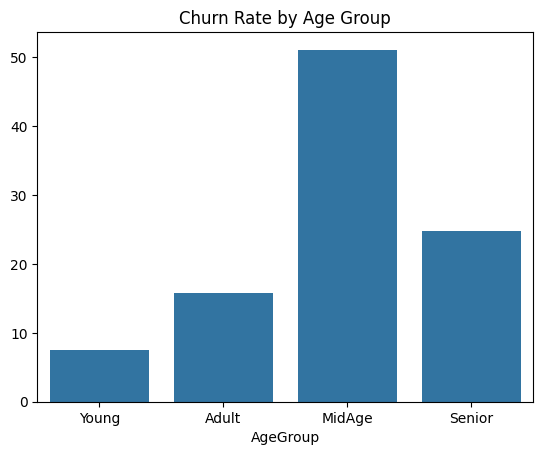

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=age_churn.index, y=age_churn.values)
plt.title("Churn Rate by Age Group")
plt.show()

In [23]:
# Overall churn
overall_churn = df['Exited'].mean()*100

# High value churn (Balance > 100k)
high_value_churn = df[df['Balance'] > 100000]['Exited'].mean()*100

# Active vs inactive
inactive_churn = df[df['IsActiveMember'] == 0]['Exited'].mean()*100

print("Overall Churn:", overall_churn)
print("High Value Churn:", high_value_churn)
print("Inactive Customer Churn:", inactive_churn)

Overall Churn: 20.369999999999997
High Value Churn: 25.234423838299648
Inactive Customer Churn: 26.850897092183956


In [25]:
from sklearn.model_selection import train_test_split

# Drop non-numeric segmentation columns
df_model = df.drop(['AgeGroup','BalanceGroup','CreditGroup','TenureGroup'], axis=1)

# Features & Target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8675

Confusion Matrix:
 [[1547   60]
 [ 205  188]]

Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1559   48]
 [ 214  179]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.79      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [31]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
Age,0.250697
Balance,0.143093
EstimatedSalary,0.138517
NumOfProducts,0.135404
CreditScore,0.131995
Tenure,0.079632
IsActiveMember,0.037793
Geography_Germany,0.028690
Gender_Male,0.021603
HasCrCard,0.018044


In [32]:
y_prob = model.predict_proba(X_test)[:,1]

In [33]:
# Try lower threshold (0.3 instead of 0.5)
y_pred_new = (y_prob > 0.3).astype(int)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[1416  191]
 [ 136  257]]
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1607
           1       0.57      0.65      0.61       393

    accuracy                           0.84      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.85      0.84      0.84      2000

